In [1]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

In [2]:
loaded_model = KeyedVectors.load_word2vec_format("eng_w2v") # 모델 로드

In [3]:
model_result = loaded_model.most_similar("man")
print(model_result)

[('woman', 0.8481197357177734), ('guy', 0.8066708445549011), ('lady', 0.7722436785697937), ('boy', 0.7576308250427246), ('girl', 0.7251576781272888), ('gentleman', 0.7123005390167236), ('soldier', 0.7051681876182556), ('kid', 0.6946446895599365), ('poet', 0.6725780367851257), ('philosopher', 0.6584644913673401)]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from gensim.models.word2vec import Word2Vec
from konlpy.tag import Okt

In [5]:
# urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt", filename="./dataset/lec07_ratings.txt")

('./dataset/lec07_ratings.txt', <http.client.HTTPMessage at 0x173009fc280>)

In [7]:
df = pd.read_table('./dataset/lec07_ratings.txt')
df[:5] # 상위 5개 출력

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        200000 non-null  int64 
 1   document  199992 non-null  object
 2   label     200000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


In [9]:
print(df.shape)
df = df.dropna(subset='document')
print(df.shape)

(200000, 3)
(199992, 3)


In [11]:
print(df.shape)
df = df.drop_duplicates(subset='document')
print(df.shape)

(199992, 3)
(194543, 3)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194543 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        194543 non-null  int64 
 1   document  194543 non-null  object
 2   label     194543 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.9+ MB


In [13]:
# 정규 표현식을 통한 한글 외 문자 제거
df['document'] = df['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_2776\3711623054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['document'] = df['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)


,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,디자인을 배우는 학생으로 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업...,1
2,4655635,폴리스스토리 시리즈는 부터 뉴까지 버릴께 하나도 없음 최고,1
3,9251303,와 연기가 진짜 개쩔구나 지루할거라고 생각했는데 몰입해서 봤다 그래 이런게 진짜 영화지,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화,1


In [ ]:
# # 불용어 정의
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize 

# stop_words_list = stopwords.words('my_korean')



In [15]:
from tqdm import tqdm

stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

# 형태소 분석기 OKT를 사용한 토큰화 작업 (다소 시간 소요)
okt = Okt()

tokenized_data = []
for sentence in tqdm(df['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    tokenized_data.append(stopwords_removed_sentence)


100%|████████████████████████████████████████| 194543/194543 [06:22<00:00, 508.05it/s]


리뷰의 최대 길이 : 72
리뷰의 평균 길이 : 10.968572500681084


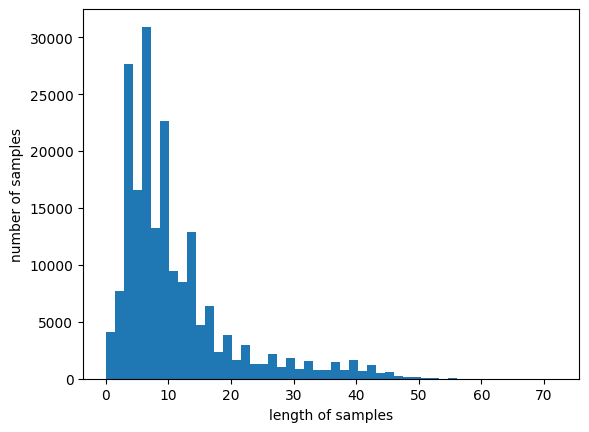

In [16]:
# 리뷰 길이 분포 확인
print('리뷰의 최대 길이 :',max(len(review) for review in tokenized_data))
print('리뷰의 평균 길이 :',sum(map(len, tokenized_data))/len(tokenized_data))
plt.hist([len(review) for review in tokenized_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [18]:
from gensim.models import Word2Vec

model = Word2Vec(sentences = tokenized_data, vector_size = 100, window = 5, min_count = 5, sg = 0)

In [19]:
# 완성된 임베딩 매트릭스의 크기 확인
model.wv.vectors.shape

(16466, 100)

In [20]:
print(model.wv.most_similar("최민식"))

[('안성기', 0.8770835995674133), ('한석규', 0.8731095194816589), ('설경구', 0.8571918606758118), ('박중훈', 0.8532732725143433), ('서영희', 0.8530150651931763), ('이민호', 0.8448230028152466), ('송강호', 0.8334672451019287), ('김수현', 0.8305975198745728), ('이정재', 0.8277725577354431), ('워싱턴', 0.8265435099601746)]


In [21]:
print(model.wv.most_similar("히어로"))

[('슬래셔', 0.8748940825462341), ('무협', 0.8503201603889465), ('호러', 0.847044050693512), ('느와르', 0.8349663615226746), ('물의', 0.8320836424827576), ('정통', 0.8124600648880005), ('무비', 0.8022733330726624), ('블록버스터', 0.7934537529945374), ('물', 0.7787160873413086), ('블랙', 0.7763715386390686)]


In [24]:
import gensim
import urllib.request

# 구글의 사전 훈련된 Word2Vec 모델을 로드.
word2vec_model = gensim.models.KeyedVectors.load_word2vec_format('./dataset/GoogleNews-vectors-negative300.bin.gz', binary=True)


In [25]:
print(word2vec_model.similarity('this', 'is'))
print(word2vec_model.similarity('post', 'book'))

0.40797037
0.057204384


In [26]:
print(word2vec_model['book'])

[ 0.11279297 -0.02612305 -0.04492188  0.06982422  0.140625    0.03039551
 -0.04370117  0.24511719  0.08740234 -0.05053711  0.23144531 -0.07470703
  0.21875     0.03466797 -0.14550781  0.05761719  0.00671387 -0.00701904
  0.13183594 -0.25390625  0.14355469 -0.140625   -0.03564453 -0.21289062
 -0.24804688  0.04980469 -0.09082031  0.14453125  0.05712891 -0.10400391
 -0.19628906 -0.20507812 -0.27539062  0.03063965  0.20117188  0.17382812
  0.09130859 -0.10107422  0.22851562 -0.04077148  0.02709961 -0.00106049
  0.02709961  0.34179688 -0.13183594 -0.078125    0.02197266 -0.18847656
 -0.17480469 -0.05566406 -0.20898438  0.04858398 -0.07617188 -0.15625
 -0.05419922  0.01672363 -0.02722168 -0.11132812 -0.03588867 -0.18359375
  0.28710938  0.01757812  0.02185059 -0.05664062 -0.01251221  0.01708984
 -0.21777344 -0.06787109  0.04711914 -0.00668335  0.08544922 -0.02209473
  0.31835938  0.01794434 -0.02246094 -0.03051758 -0.09570312  0.24414062
  0.20507812  0.05419922  0.29101562  0.03637695  0.04